#Credit Risk Assessment

##1. Load the Data

- We will bring in the loan applicant data.
- This data has details like income, age, and loan amount.
- It also tells us who repaid and who defaulted.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


#2. Exploratory Data Analysis (EDA)

- Here we simply look at the data before touching it.
- We want to understand it first, then work on it.

###Basic info about the data

- Check how many rows and columns we have.
- Check the data type of each column.

In [4]:
df.shape
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


#Missing values

- Find out which columns have empty or missing values.
- This tells us where we may need to fix things later.

In [5]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


#Target balance

- Check how many people defaulted vs how many repaid.
- This tells us if our data is balanced or imbalanced.

In [6]:
df.head()
df['loan_status'].unique()

df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


<Axes: xlabel='loan_status', ylabel='count'>

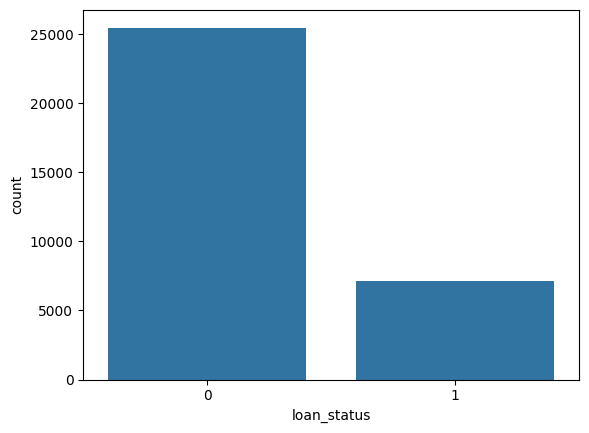

In [7]:
sns.countplot(x='loan_status', data=df)

#Outlier check

- Look for values that seem impossible, like age 144.
- These are signs of bad data entries.

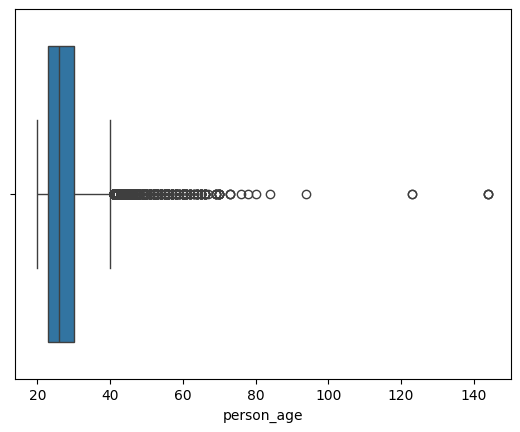

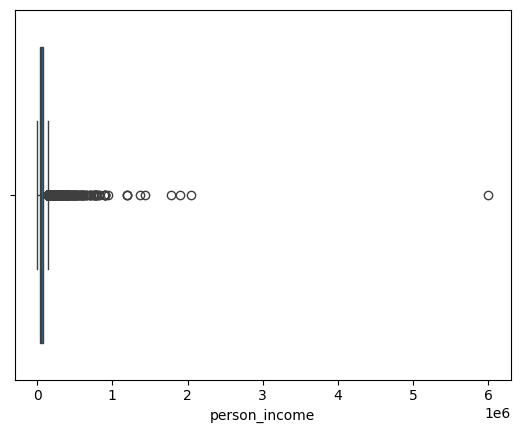

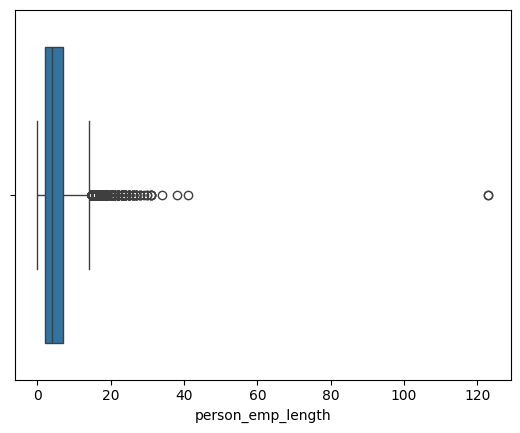

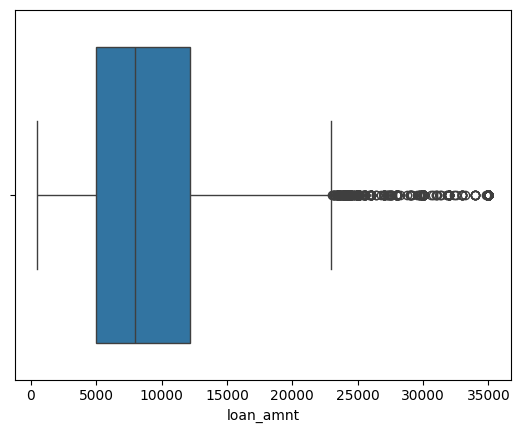

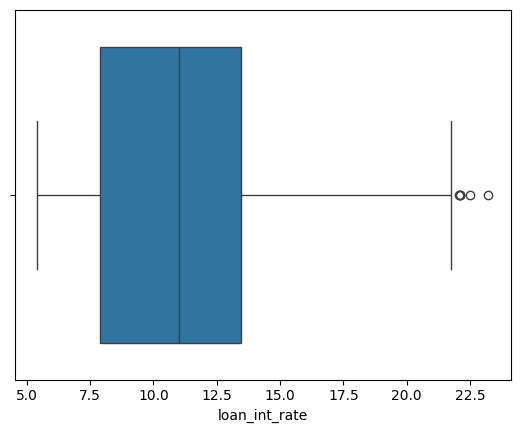

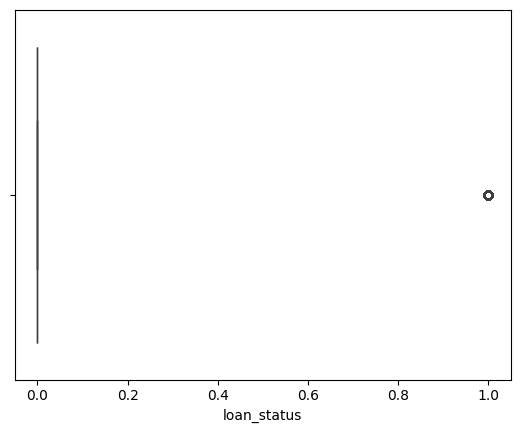

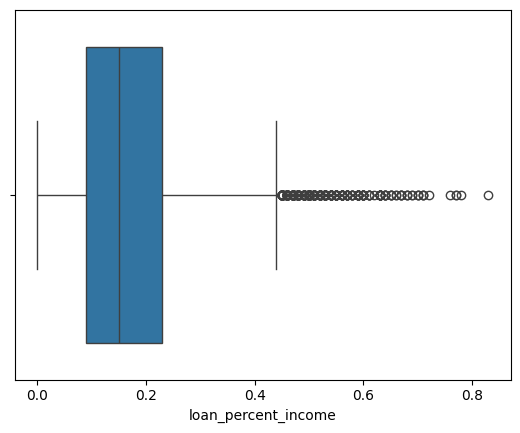

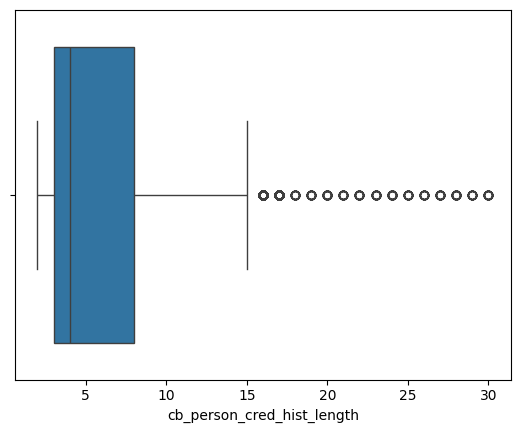

In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns

for i in numerical_cols:
  sns.boxplot(x=df[i])
  plt.show()

In [9]:
(df['person_age'] > 100).sum()

np.int64(5)

In [10]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

In [11]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


##Correlation check

- See how strongly features are related to each other.
- This helps us spot repeated or linked information.

<Axes: >

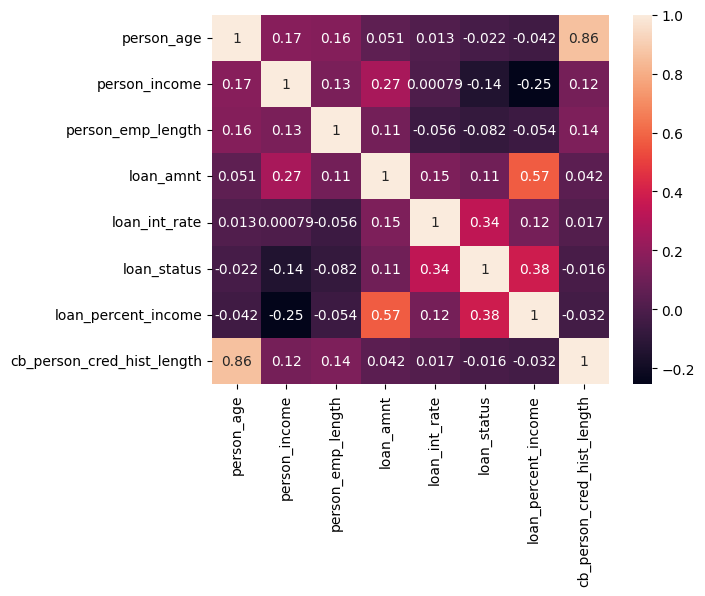

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

#3. Data Validation & Outlier Handling

- Here we clean the data properly.
- We remove duplicate rows.
- We remove rows with an impossible age or work experience.
- We remove rows with zero or negative income and loan amount.
- We check if the interest rate looks realistic.
- We also flag rows where numbers don't add up correctly.

In [13]:
df_copy = df.copy() # we make a copy of dataset
print(f"Original Rows: {df_copy.shape[0]}")

#Remove Duplicate rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing Duplicates: {df_copy.shape[0]}")

#Remove ages below 18 or above 100
df_copy = df_copy[df_copy['person_age'] >= 18]
df_copy = df_copy[df_copy['person_age'] < 100]

#Remove employee length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

#Remove rows with 0 or negative income andloan amount
df_copy = df_copy[df_copy['loan_amnt'] > 0]

#check interest rate is realistic
print("Loan Interest Rate from (min: 5.42 and max: 23.22)")

Original Rows: 32581
Rows after removing Duplicates: 32416
Loan Interest Rate from (min: 5.42 and max: 23.22)


In [14]:
df_copy.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31522.000000,3.152200e+04,31522.000000,31522.000000,28495.000000,31522.000000,31522.000000,31522.000000
mean,27.742529,6.650168e+04,4.782850,9663.771334,11.045220,0.215944,0.169658,5.816097
std,6.218713,5.275216e+04,4.037343,6334.787700,3.230786,0.411482,0.106296,4.063622
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.943800e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


#4. Features, Target & Train-Test Split

- We separate the data into input features and the target.
- The target is whether the applicant defaulted or not.
- We split the data into a training part and a testing part.
- The model learns from the training part only.

In [15]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

#5. Handle Class Imbalance

- Very few people actually default in this data.
- If we ignore this, the model may just favor the majority class.
- We give more importance to the minority class during training.
- This helps the model actually learn to spot defaulters.

In [18]:
# 0 no loan
# 1 yes

y_train.value_counts()

,count
loan_status,
0,19772
1,5445


In [19]:
neg, pos = np.bincount(y_train) #negative and positive
scale_weights = neg / pos
scale_weights

np.float64(3.6312213039485766)

In [20]:
neg

np.int64(19772)

In [21]:
pos

np.int64(5445)

#6. Data Preprocessing — Pipelines & Column Transformer

- Raw data is not ready for a model directly.
- We need to prepare numeric and text columns differently.
- We will build a Pipeline for each model.
- We will use ColumnTransformer to apply different steps to different columns.

##Preprocessing for Logistic Regression

- Fill missing numeric values.
- Scale numeric values, since this model is sensitive to scale.
- Convert category columns into numbers using one-hot encoding.

In [22]:
#Logistic regression : impute + SCALE Numeric, impute + One-Hot-Encoding
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        #Pipeline for numerical columns
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scalar', StandardScaler())
        ]), numeric_cols),

        #Pipeline for categorical columns
         ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant',fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

##Preprocessing for XGBoost

- Fill missing numeric values.
- No scaling needed here, since tree models don't need it.
- Convert category columns into numbers using one-hot encoding.


In [23]:
#XGBoost: Impute numeric only (No Scaling), impute + One - Hot Encoding
preprocessor_xg = ColumnTransformer(
    transformers=[
        #Pipeline for numerical columns
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scalar', StandardScaler())
        ]), numeric_cols),

        #Pipeline for categorical columns
         ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant',fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

#7. Evaluation Helper Function

- We build one common function to check any model's performance.
- It will show accuracy, precision, recall, F1 score, and more.
- It will also show a confusion matrix and a precision-recall curve.

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve, classification_report
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

#Metrices
  accuracy = accuracy_score(y_test, y_pred) #Overall Model's Performance
  precision = precision_score(y_test, y_pred) #of the ones i picked how many were actually right?
  recall = recall_score(y_test, y_pred) #out of everything that was really there, how much did you find out to manage
  f1 = f1_score(y_test, y_pred) #harmonic mean of precision and recall

# Confusion Matrix
  cm = confusion_matrix(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)

  print(f"{model_name} Metrics:")
  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy: {accuracy:.2f}")
  print(f"Precision: {precision:.2f}")
  print(f"Recall: {recall:.2f}")
  print(f"F1: {f1:.2f}")
  print()
  print(f"{model_name}")
  print(class_report)

  #Plotting
  sns.heatmap(cm, annot=True, fmt="d") #fmt is format and d is decimal
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()

  #Plotting ROC-AUC curve
  precision, recall, threshold = precision_recall_curve(y_test,y_prob)
  plt.plot(recall, precision)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

#8. Stratified Cross-Validation

- One single train-test split may not be reliable.
- We split the training data into five folds instead.
- Each fold keeps the same default vs repaid ratio.
- We check the model's score across all folds.

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=True)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [26]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [27]:
#XG Boost
import pip
!pip install xgboost

from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
    n_estimator=300, max_depth=5, learning_rate=0.1,
    scale_pos_weights=scale_weights,random_state=42))
])

xgb_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_valu...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimator=300, n_estimators=None, n_jobs=None, ...))])

In [28]:
for cv_name, pipe in [('Logistic Regression', lr_cv_pipeline),
                      ('XGBoost', xgb_cv_pipeline)]:

                      cv_results = cross_validate(
                          pipe,
                          X_train,
                          y_train,
                          cv=cv,
                          scoring=scoring,
                          n_jobs=-1)

                      print(cv_name)
                      print(f"ROC-AUC: {cv_results['test_roc_auc'].mean()}")
                      print(f"Accuracy: {cv_results['test_accuracy'].mean()}")
                      print(f"Precision: {cv_results['test_precision'].mean()}")
                      print(f"Recall: {cv_results['test_recall'].mean()}")
                      print(f"F1: {cv_results['test_f1'].mean()}")
                      print()

Logistic Regression
ROC-AUC: 0.8706739431147925
Accuracy: 0.8119125874340309
Precision: 0.5452663651328141
Recall: 0.7766758494031221
F1: 0.6406927611333023

XGBoost
ROC-AUC: 0.9385074245623946
Accuracy: 0.9342507881859152
Precision: 0.971489168619789
Recall: 0.7166207529843893
F1: 0.8246522502085618



In [29]:
cv_results

{'fit_time': array([0.81579876, 0.87644839, 1.30777454, 1.14491582, 1.15739465]),
 'score_time': array([0.20104098, 0.13759208, 0.2031281 , 0.17289352, 0.34204125]),
 'test_roc_auc': array([0.93716176, 0.94414923, 0.93450716, 0.93924809, 0.93747088]),
 'test_accuracy': array([0.92842982, 0.93794607, 0.93357129, 0.93595082, 0.93535594]),
 'test_precision': array([0.97769029, 0.96859903, 0.9620098 , 0.97167488, 0.97747184]),
 'test_recall': array([0.68411387, 0.73645546, 0.72084481, 0.72451791, 0.71717172]),
 'test_f1': array([0.80497029, 0.83672405, 0.82414698, 0.83008943, 0.82733051])}

In [30]:
import xgboost
import sklearn

print("XGBoost:", xgboost.__version__)
print("Scikit-learn:", sklearn.__version__)

XGBoost: 3.4.1
Scikit-learn: 1.6.1


#9. Baseline Model — Logistic Regression

- We start with a simple model first.
- This becomes our benchmark to beat.
- We train it and check its score on the test data.

In [31]:
from sklearn.pipeline import Pipeline
baseline_model = Pipeline([
    ('Preprocessor', preprocessor_lr),
    ('Classifier', LogisticRegression(class_weight='balanced'))
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('Classifier', LogisticRegression(class_weight='balanced'))])

Baseline Logistic Model Metrics:
Accuracy: 0.82
Precision: 0.56
Recall: 0.79
F1: 0.65

Baseline Logistic Model
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



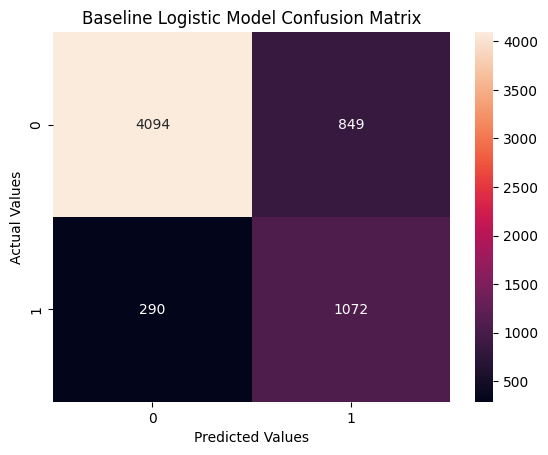

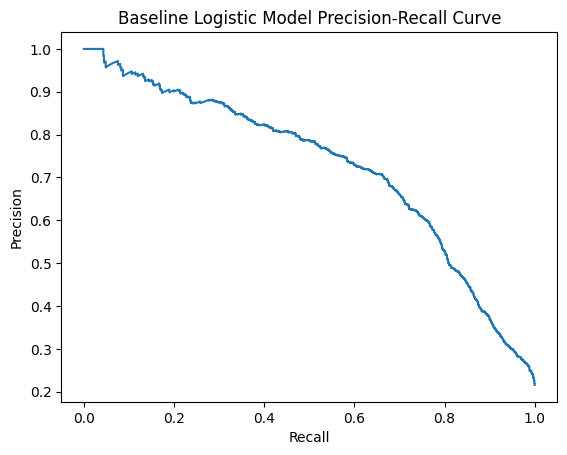

In [32]:
#Evaluate logistic model
evaluate_model("Baseline Logistic Model", baseline_model, X_test, y_test)

#10. XGBoost Hyperparameter Tuning

- Now we move to a stronger model, XGBoost.
- A model has many settings called hyperparameters.
- We search for the best combination of these settings.
- We use cross-validation while searching, so the result is reliable.

In [33]:
xg_model = Pipeline([
    ('Preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1,
      scale_pos_weight=scale_weights, random_state=42))
])
xg_model.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_valu...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

XGBoost Metrics:
Accuracy: 0.92
Precision: 0.82
Recall: 0.79
F1: 0.81

XGBoost
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4943
           1       0.82      0.79      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



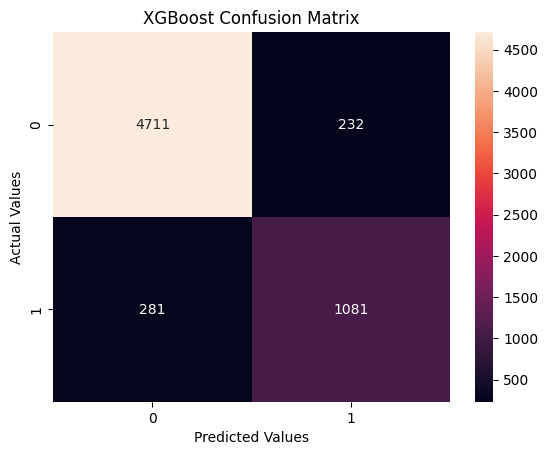

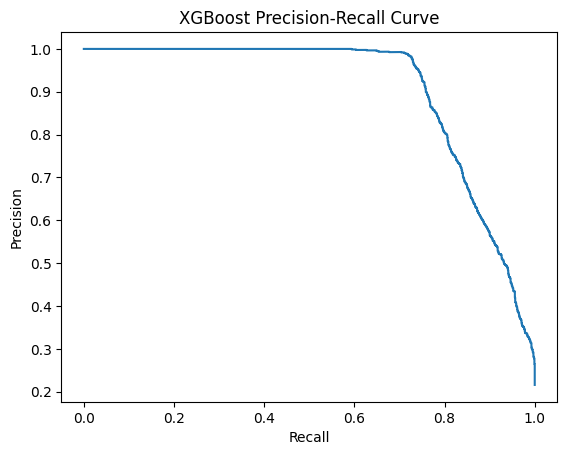

In [34]:
evaluate_model("XGBoost", xg_model, X_test, y_test)

#10. XGBoost Hyperparameter Tuning

- Now we move to a stronger model, XGBoost.
- A model has many settings called hyperparameters.
- We search for the best combination of these settings.
- We use cross-validation while searching, so the result is reliable.

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
param_grid = {
    "classifier__n_estimators": randint(150,600),
    "classifier__max_depth": randint(3,9),
    "classifier__learning_rate": uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6, 0.4), #Rows sampling
    "classifier__colsample_bytree": uniform(0.6, 0.4), #Column sampling
    "classifier__min_child_weight": uniform(1, 10),
    "classifier__gamma": uniform(0, 5)
}
# lower gamma -> more splits -> complex tree -> higher overfitting risk
# higher gamma -> less splits ->  simpler tree -> low overfitting

In [36]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=True, shuffle=True),
                   estimator=Pipeline(steps=[('Preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scalar',
                                                                                                StandardScaler())]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_incom...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x77ffe1621a70>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x77ffda53b380>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x77ffda5b2fd0>},
                   scoring='average_precision', verbose=1)

In [37]:
print(f"Score after performing Tuning {random_search.best_score_:.2f}")

Score after performing Tuning 0.90


In [38]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.6638887951925347),
 'classifier__gamma': np.float64(3.0323606966459478),
 'classifier__learning_rate': np.float64(0.12148815812460916),
 'classifier__max_depth': 7,
 'classifier__min_child_weight': np.float64(9.048005140185131),
 'classifier__n_estimators': 487,
 'classifier__subsample': np.float64(0.8484032560328826)}

#11. Compare Both Models Side by Side

- We now compare Logistic Regression and XGBoost.
- We look at their scores together in one table.
- This helps us pick the better performing model.

Logistic Regression Metrics:
Accuracy: 0.82
Precision: 0.56
Recall: 0.79
F1: 0.65

Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



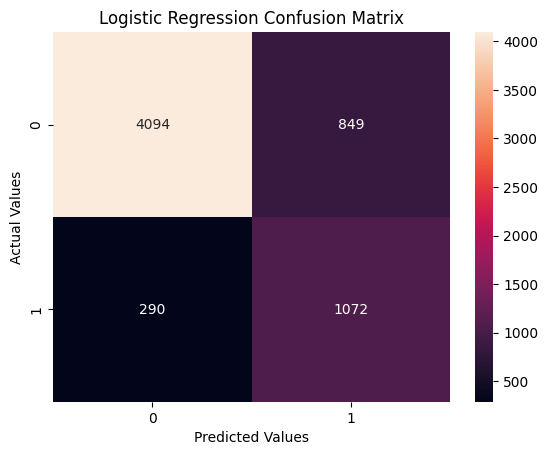

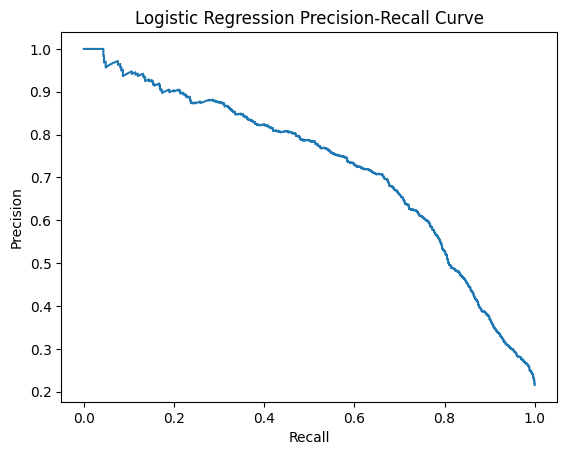

In [39]:
evaluate_model("Logistic Regression", baseline_model, X_test, y_test)

XGBoost Metrics:
Accuracy: 0.92
Precision: 0.82
Recall: 0.81
F1: 0.81

XGBoost
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4943
           1       0.82      0.81      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.88      0.88      6305
weighted avg       0.92      0.92      0.92      6305



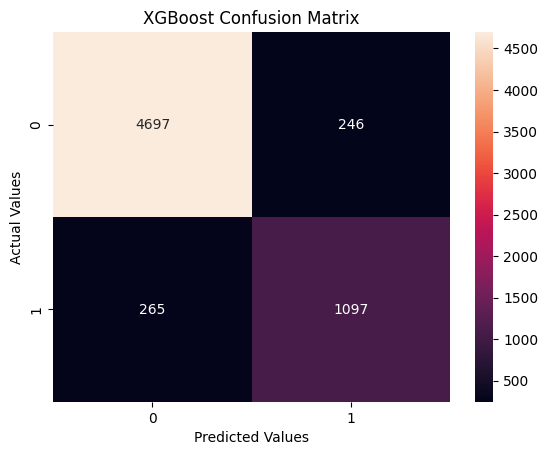

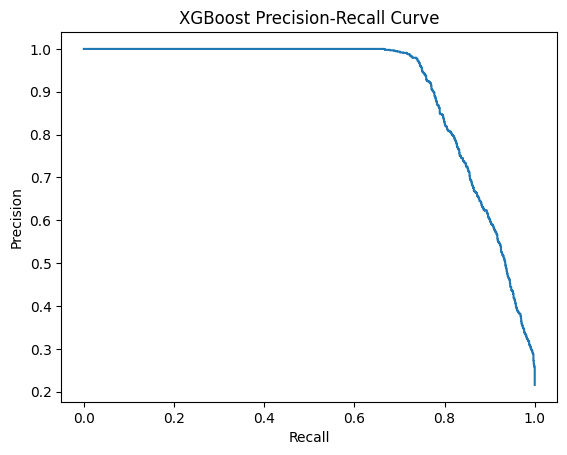

In [40]:
#Passing the XGBoost model after performing Hyperparameter Tuning
evaluate_model("XGBoost", random_search, X_test, y_test)

#12. Optimizing the Classification Threshold

- The model gives a probability, not a direct yes or no.
- We decide a cut-off point to turn it into a decision.
- We check different cut-off points and pick the best one.

XGBoost Metrics:
Used Threshold : 1.00
Accuracy: 0.78
Precision: 0.00
Recall: 0.00
F1: 0.00

XGBoost
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4943
           1       0.00      0.00      0.00      1362

    accuracy                           0.78      6305
   macro avg       0.39      0.50      0.44      6305
weighted avg       0.61      0.78      0.69      6305



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

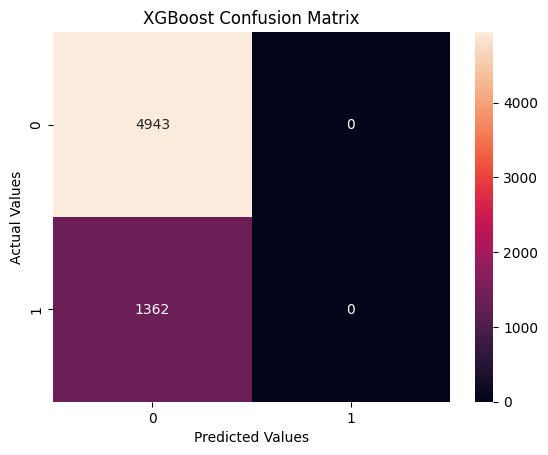

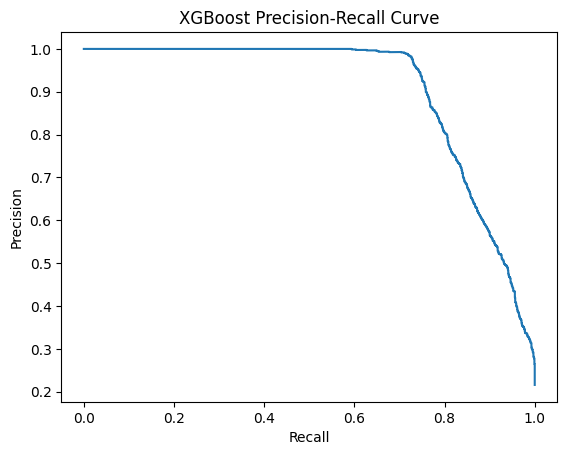

In [41]:
#Get the prob. of class 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:, 1]

#For each threshold calculate Precision and Recall
precisions, recalls , thresholds = precision_recall_curve(y_test, prob)


#Calculate F1 score for each threshold
f1 = 2 * (precisions-recalls) / (precisions + recalls + 1e-9)

#Get the threshold that produces the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

#Evaluate the XGBoost model using that threshold.
evaluate_model("XGBoost", xg_model, X_test, y_test, best_threshold)

#13. Probability Calibration

- Sometimes a model's probability doesn't mean what it says.
- For example, 30% risk should truly mean a 30% chance.
- We check this with a calibration plot.
- We fix it if the probabilities are off.


In [42]:
"""
Methods by which we can fix the poorly calibrated model.
1. Platt Scaling/ Sigmoid -> Adjust the probabilites using a sigmoid curve.
2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob. (non-linear calibartion)
3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature
"""

'\nMethods by which we can fix the poorly calibrated model.\n1. Platt Scaling/ Sigmoid -> Adjust the probabilites using a sigmoid curve.\n2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob. (non-linear calibartion)\n3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature\n'

In [43]:
#1. Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('Preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scalar',
                                                                                                    StandardScaler())]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(ste...
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.12148815812460916),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=7,
                                                                max_leaves=None,
                                                                min_child_weight=np.float64(9.048005140185131),
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=487,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [44]:
#2. Get probabilities
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]

In [45]:
calibrated

array([0.44020202, 0.02433706, 0.94852276, ..., 0.4626109 , 0.01922831,
       0.01345139])

In [46]:
uncalibrated

array([0.8254656 , 0.25111562, 0.9782833 , ..., 0.48520026, 0.07587515,
       0.05467961], dtype=float32)

In [47]:
#3. Create calibration curve
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

In [48]:
actual_cal, predicted_cal = calibration_curve(y_test, calibrated, n_bins=10)

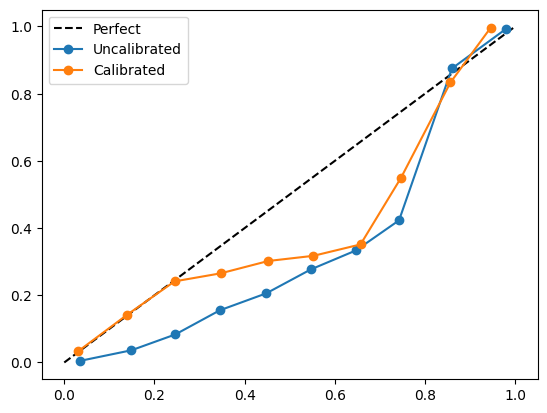

In [49]:
#plot
plt.plot([0,1], [0,1], 'k--', label="Perfect")

plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label="Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label="Calibrated"
)

plt.legend()

In [71]:
xgb_model = calibrated_model.calibrated_classifiers_[0].estimator.named_steps['classifier']

print(type(xgb_model))
print(xgb_model.get_booster())

<class 'xgboost.sklearn.XGBClassifier'>


In [72]:
xgb_model.save_model("xgb_test.json")
print("SAVED")

SAVED


In [73]:
from xgboost import XGBClassifier

test_model = XGBClassifier()
test_model.load_model("xgb_test.json")

print("XGBoost model loaded successfully")

XGBoost model loaded successfully


In [75]:
print(type(calibrated_model))
print(len(calibrated_model.calibrated_classifiers_))

for i, c in enumerate(calibrated_model.calibrated_classifiers_):
    print(i, type(c.estimator), type(c.calibrators[0]))

<class 'sklearn.calibration.CalibratedClassifierCV'>
5
0 <class 'sklearn.pipeline.Pipeline'> <class 'sklearn.calibration._SigmoidCalibration'>
1 <class 'sklearn.pipeline.Pipeline'> <class 'sklearn.calibration._SigmoidCalibration'>
2 <class 'sklearn.pipeline.Pipeline'> <class 'sklearn.calibration._SigmoidCalibration'>
3 <class 'sklearn.pipeline.Pipeline'> <class 'sklearn.calibration._SigmoidCalibration'>
4 <class 'sklearn.pipeline.Pipeline'> <class 'sklearn.calibration._SigmoidCalibration'>


#14. SHAP Interpretation — Global & Local

- SHAP helps us understand why the model makes a decision.
- It is a way of explaining a "black box" model.

In [50]:
!pip install shap
import shap

In [51]:
#2. Get the Trained XGBoost classifier model out of the pipeline.
# taking the base model
xgb_classifier = xg_model.named_steps['classifier']

In [52]:
#3. Transform X_test using the same preprocessing used for training.
X_test_transformed = xg_model.named_steps['Preprocessor'].transform(X_test)

In [53]:
#4. Get feature names after one-hot enocding , so plots are readable
feature_names = xg_model.named_steps['Preprocessor'].get_feature_names_out()

In [54]:
#5. Convert to a dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)
X_test_df

,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
0,-0.597236,-0.707342,-0.935934,0.850530,1.508838,3.113936,-0.690114,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.759282,-0.125160,0.302506,2.528276,-0.017662,2.455002,-0.442390,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.212991,-0.940215,-0.688246,-0.953839,1.375392,0.289933,0.053058,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.699128,1.233265,0.550194,0.533974,0.535654,-0.651401,0.548506,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.759282,-0.410662,0.550194,1.721058,-0.583997,2.643269,-0.937838,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6300,-1.083373,0.165931,0.054818,1.641919,0.672355,0.948867,-0.937838,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6301,0.212991,3.853084,-0.688246,2.433309,0.070218,-0.745534,1.043953,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6302,-0.435191,-0.338704,0.797882,-0.732250,-0.378944,-0.651401,-0.937838,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6303,-0.111100,0.942174,1.540945,-0.257416,-1.150331,-0.933801,0.300782,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [55]:
#6. Create SHAP explainer built for tree-based model
explainer = shap.TreeExplainer(xgb_classifier)

In [56]:
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-1.7525564e-01, -1.0555401e-01,  1.2984274e-01, ...,
        -7.3516299e-03, -3.8879909e-02,  0.0000000e+00],
       [ 4.7165085e-02, -8.7262326e-01, -9.4737314e-02, ...,
        -9.2151780e-03, -7.5508673e-03,  0.0000000e+00],
       [ 7.8027323e-02,  3.5025654e+00,  1.2711690e-01, ...,
        -7.3584518e-03,  7.7456667e-04,  0.0000000e+00],
       ...,
       [-8.6244913e-03,  5.8208084e-01,  7.2391242e-02, ...,
        -9.2837382e-03, -1.1459960e-02,  0.0000000e+00],
       [ 2.0838849e-02, -1.0313793e+00,  4.3692421e-02, ...,
        -9.2305308e-03, -1.1398584e-02,  0.0000000e+00],
       [-1.3665082e-01, -5.0866711e-01,  2.6854105e-02, ...,
        -8.8342456e-03, -1.0388625e-02,  0.0000000e+00]], dtype=float32)

##Global shap explanation

- This shows which features matter most overall.
- It also shows if a feature increases or decreases risk.

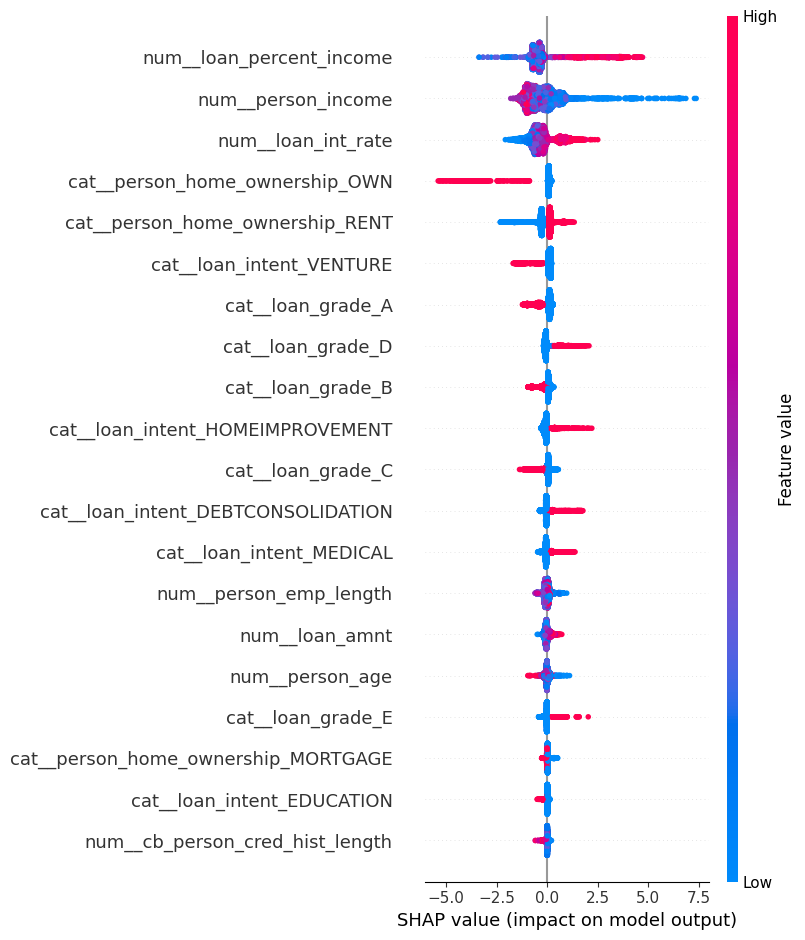

In [57]:
shap.summary_plot(shap_values, X_test_df)

##Local shap explanation

- This shows why one specific applicant got their score.
- It breaks the score down feature by feature.

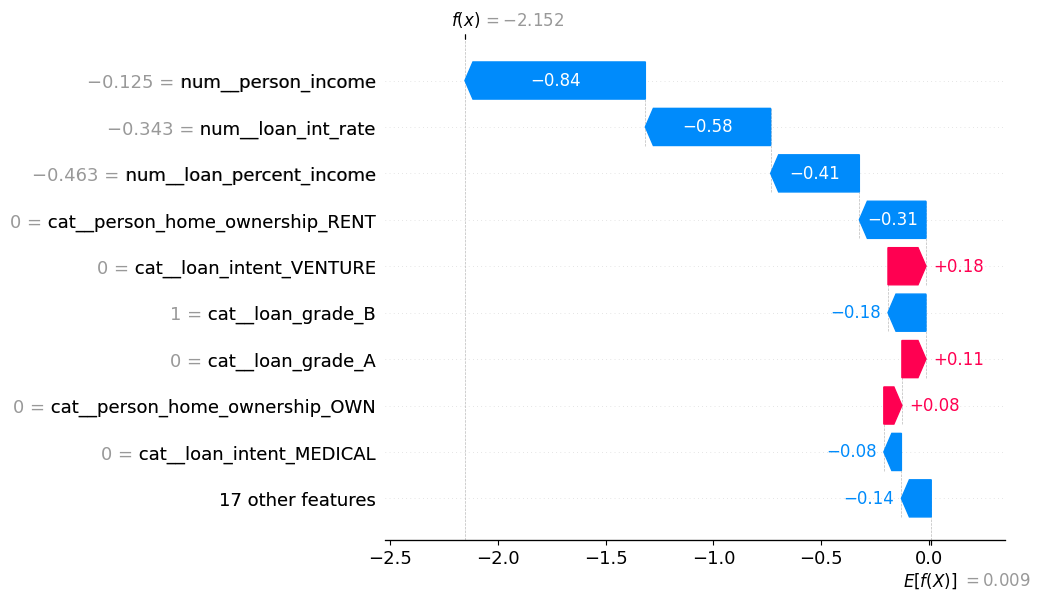

In [58]:
# 1. Pick one row to explain, e.g. the 5th applicant in the test set
row_index = 5

#2. Draw a waterfall plot showing how each feature pushed the prediction up or down.
#local shap
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

#15. Analyzing False Positives & False Negatives

- The model will not be perfect.
- False positives are safe people wrongly marked risky.
- False negatives are risky people wrongly marked safe.
- We study these cases to understand where the model struggles.

In [59]:
#Get predictions from the best performing XGBoost model on the test set
y_pred = random_search.predict(X_test)

In [60]:
#Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [61]:
result_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted
14455,24,30000,OWN,1.0,MEDICAL,E,15000,15.68,0.50,N,3,1,0
8701,23,60000,MORTGAGE,6.0,EDUCATION,C,25600,NaN,0.43,N,4,0,0
19804,29,18000,RENT,2.0,EDUCATION,C,3600,15.27,0.20,N,6,1,1
27252,32,130000,MORTGAGE,7.0,MEDICAL,B,13000,12.69,0.10,N,8,0,0
5610,23,45288,MORTGAGE,7.0,DEBTCONSOLIDATION,B,20500,9.25,0.45,N,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11661,21,75000,MORTGAGE,5.0,PERSONAL,C,20000,13.11,0.27,Y,2,0,0
27837,29,265000,MORTGAGE,2.0,PERSONAL,B,25000,11.26,0.09,N,10,0,0
17192,25,48996,MORTGAGE,8.0,MEDICAL,B,5000,9.88,0.10,N,2,1,1
26858,27,115000,MORTGAGE,11.0,MEDICAL,A,8000,7.51,0.07,N,7,0,0


In [62]:
#Identify False Positive : Model Predicted 1, but the actual was 0
false_positive = result_df[(result_df['actual'] == 0) & (result_df['predicted'] == 1)]

#Identify False Negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual'] == 1) & (result_df['predicted'] == 0)]

In [63]:
print(f"False Positive {len(false_positive)}")
print(f"False Negative {len(false_negative)}")

False Positive 246
False Negative 265


In [64]:
#False Negative > False Positive

#16. Save the Final Model

- Once we are happy with the model, we save it.
- We also save the settings it needs, like the chosen threshold.
- This saved file can now be used in a real application.

In [76]:
import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [70]:
import xgboost
import sklearn

print("XGBoost:", xgboost.__version__)
print("Scikit-learn:", sklearn.__version__)

XGBoost: 3.4.1
Scikit-learn: 1.6.1


In [66]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Get probabilities from the CALIBRATED model, not the old XG_model
calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]

# 2. Re-run the same threshold search, now on the correct probability scale
precisions, recalls, thresholds = precision_recall_curve(
    y_test, calibrated_proba
)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print("New threshold:", best_threshold)

New threshold: 0.6809786261379365


In [77]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']